## Regression: Predicting Attraction Ratings

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
data=pd.read_csv("../Data/final_data.csv")
data.head()

,useridx,continent,region,usercountry,usercity,transactionid,visityearx,visitmonthx,attractionidx,ratingx,visitmodex,attraction,attractionaddress,attractiontype,attractioncity,attractioncountry
0,14,Europe,Southern Europe,Portugal,Lagos,5661,2018,12,640,4,Friends,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,Cameroon
1,14,Europe,Southern Europe,Portugal,Lagos,67652,2018,12,748,5,Friends,Tegalalang Rice Terrace,"Jalan Raya Ceking, Tegalalang 80517 Indonesia",Points of Interest & Landmarks,Douala,Cameroon
2,14,Europe,Southern Europe,Portugal,Lagos,68777,2018,12,748,5,Friends,Tegalalang Rice Terrace,"Jalan Raya Ceking, Tegalalang 80517 Indonesia",Points of Interest & Landmarks,Douala,Cameroon
3,16,Asia,South East Asia,Indonesia,Jakarta,4735,2018,4,640,5,Family,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,Cameroon
4,16,Asia,South East Asia,Indonesia,Jakarta,5318,2017,12,640,5,Friends,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,Cameroon


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 52930 entries, 0 to 52929
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   useridx            52930 non-null  int64
 1   continent          52930 non-null  str  
 2   region             52930 non-null  str  
 3   usercountry        52930 non-null  str  
 4   usercity           52922 non-null  str  
 5   transactionid      52930 non-null  int64
 6   visityearx         52930 non-null  int64
 7   visitmonthx        52930 non-null  int64
 8   attractionidx      52930 non-null  int64
 9   ratingx            52930 non-null  int64
 10  visitmodex         52930 non-null  str  
 11  attraction         52930 non-null  str  
 12  attractionaddress  52930 non-null  str  
 13  attractiontype     52930 non-null  str  
 14  attractioncity     52930 non-null  str  
 15  attractioncountry  52930 non-null  str  
dtypes: int64(6), str(10)
memory usage: 13.1 MB


In [5]:
data.dropna(axis=0,inplace=True)
data.info()

<class 'pandas.DataFrame'>
Index: 52922 entries, 0 to 52929
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   useridx            52922 non-null  int64
 1   continent          52922 non-null  str  
 2   region             52922 non-null  str  
 3   usercountry        52922 non-null  str  
 4   usercity           52922 non-null  str  
 5   transactionid      52922 non-null  int64
 6   visityearx         52922 non-null  int64
 7   visitmonthx        52922 non-null  int64
 8   attractionidx      52922 non-null  int64
 9   ratingx            52922 non-null  int64
 10  visitmodex         52922 non-null  str  
 11  attraction         52922 non-null  str  
 12  attractionaddress  52922 non-null  str  
 13  attractiontype     52922 non-null  str  
 14  attractioncity     52922 non-null  str  
 15  attractioncountry  52922 non-null  str  
dtypes: int64(6), str(10)
memory usage: 13.5 MB


In [6]:
data.describe()

,useridx,transactionid,visityearx,visitmonthx,attractionidx,ratingx
count,52922.000000,52922.000000,52922.000000,52922.000000,52922.000000,52922.000000
mean,45025.888364,70418.108783,2016.351971,6.632497,759.672272,4.157609
std,25072.959559,66303.526122,1.732955,3.392764,210.730158,0.970575
min,14.000000,3.000000,2013.000000,1.000000,369.000000,1.000000
25%,23470.000000,19645.250000,2015.000000,4.000000,640.000000,4.000000
50%,45533.500000,42770.500000,2016.000000,7.000000,737.000000,4.000000
75%,66670.250000,105640.750000,2018.000000,9.000000,841.000000,5.000000
max,88190.000000,211241.000000,2022.000000,12.000000,1297.000000,5.000000


In [7]:
y=data.ratingx
y[:5]

0    4
1    5
2    5
3    5
4    5
Name: ratingx, dtype: int64

In [8]:
x=data.drop("ratingx",axis=1)
x.head()

,useridx,continent,region,usercountry,usercity,transactionid,visityearx,visitmonthx,attractionidx,visitmodex,attraction,attractionaddress,attractiontype,attractioncity,attractioncountry
0,14,Europe,Southern Europe,Portugal,Lagos,5661,2018,12,640,Friends,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,Cameroon
1,14,Europe,Southern Europe,Portugal,Lagos,67652,2018,12,748,Friends,Tegalalang Rice Terrace,"Jalan Raya Ceking, Tegalalang 80517 Indonesia",Points of Interest & Landmarks,Douala,Cameroon
2,14,Europe,Southern Europe,Portugal,Lagos,68777,2018,12,748,Friends,Tegalalang Rice Terrace,"Jalan Raya Ceking, Tegalalang 80517 Indonesia",Points of Interest & Landmarks,Douala,Cameroon
3,16,Asia,South East Asia,Indonesia,Jakarta,4735,2018,4,640,Family,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,Cameroon
4,16,Asia,South East Asia,Indonesia,Jakarta,5318,2017,12,640,Friends,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,Cameroon


In [9]:
data.ratingx.value_counts()

ratingx
5    23930
4    17964
3     7730
2     2035
1     1263
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x296bf310050>,
 [Text(0.16465051812661285, 1.0876075610626463, '5'),
  Text(-0.7928364903848316, -0.762502655414565, '4'),
  Text(0.7256261725708605, -0.8267204229243186, '3'),
  Text(1.0599268306775527, -0.2942025044248246, '2'),
  Text(1.0969097734224982, -0.0823950785557251, '1')],
 [Text(0.089809373523607, 0.5932404878523525, '45.22%'),
  Text(-0.4324562674826354, -0.41591053931703537, '33.94%'),
  Text(0.39579609412956024, -0.45093841250417366, '14.61%'),
  Text(0.5781419076423013, -0.1604740933226316, '3.85%'),
  Text(0.598314421866817, -0.04494277012130459, '2.39%')])

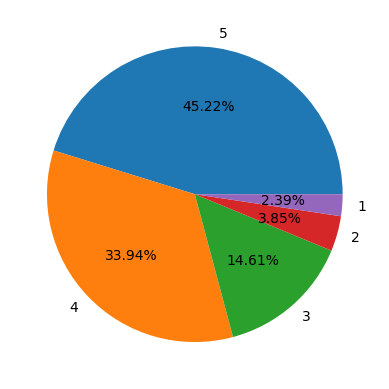

In [10]:
plt.pie(data.ratingx.value_counts(),labels=data.ratingx.value_counts().index,autopct="%1.2f%%")

In [11]:
numerical=[cols for cols in x.columns if x[cols].dtype!="str"]
categorical=[cols for cols in x.columns if cols not in numerical]
print(f"Numerical {numerical} \nCategorical {categorical}")

Numerical ['useridx', 'transactionid', 'visityearx', 'visitmonthx', 'attractionidx'] 
Categorical ['continent', 'region', 'usercountry', 'usercity', 'visitmodex', 'attraction', 'attractionaddress', 'attractiontype', 'attractioncity', 'attractioncountry']


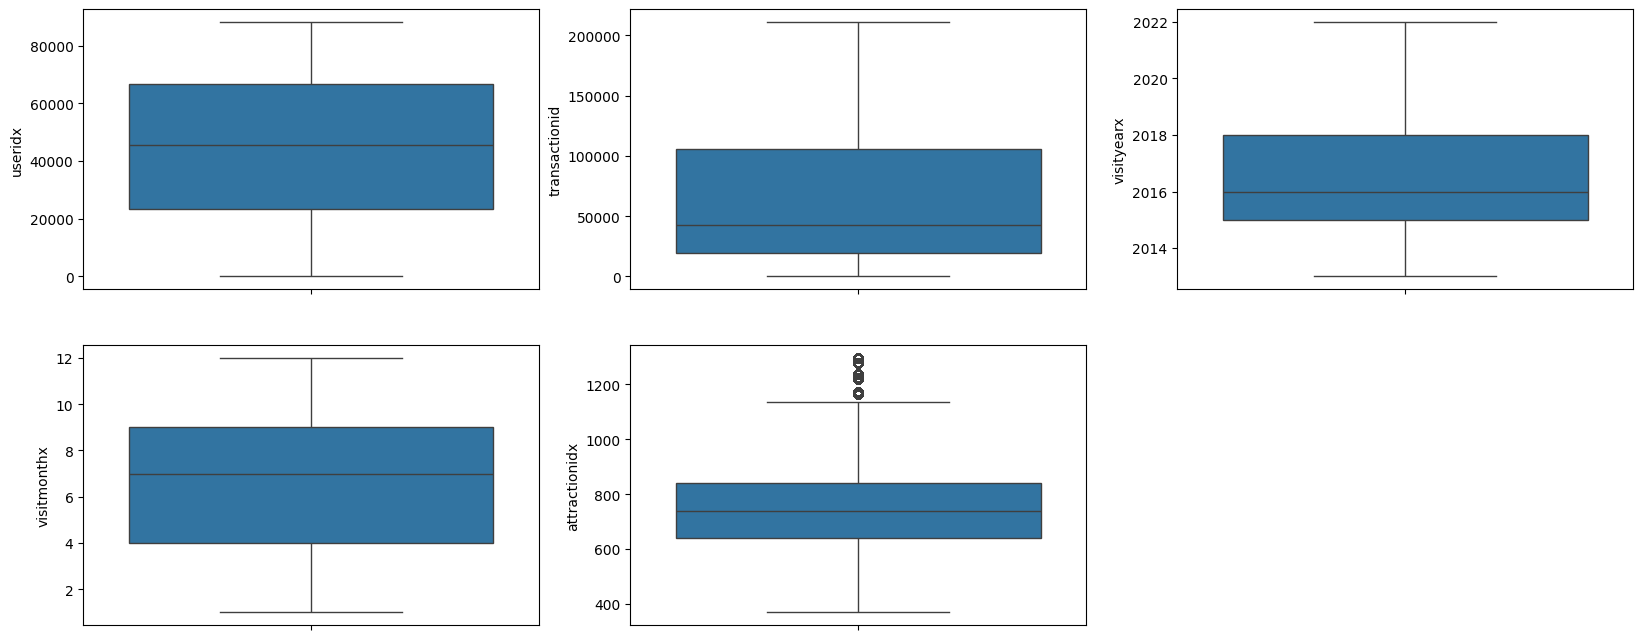

In [12]:
#Here we are analysing outliers for numerical features
k=0
plt.figure(figsize=(20,8))
for i in range(5):
    plt.subplot(2,3,k+1)
    sns.boxplot(x[numerical[k]])
    k+=1

In [13]:
x.skew(numeric_only=True)

useridx         -0.057096
transactionid    1.024275
visityearx       0.081844
visitmonthx     -0.078865
attractionidx    0.884521
dtype: float64

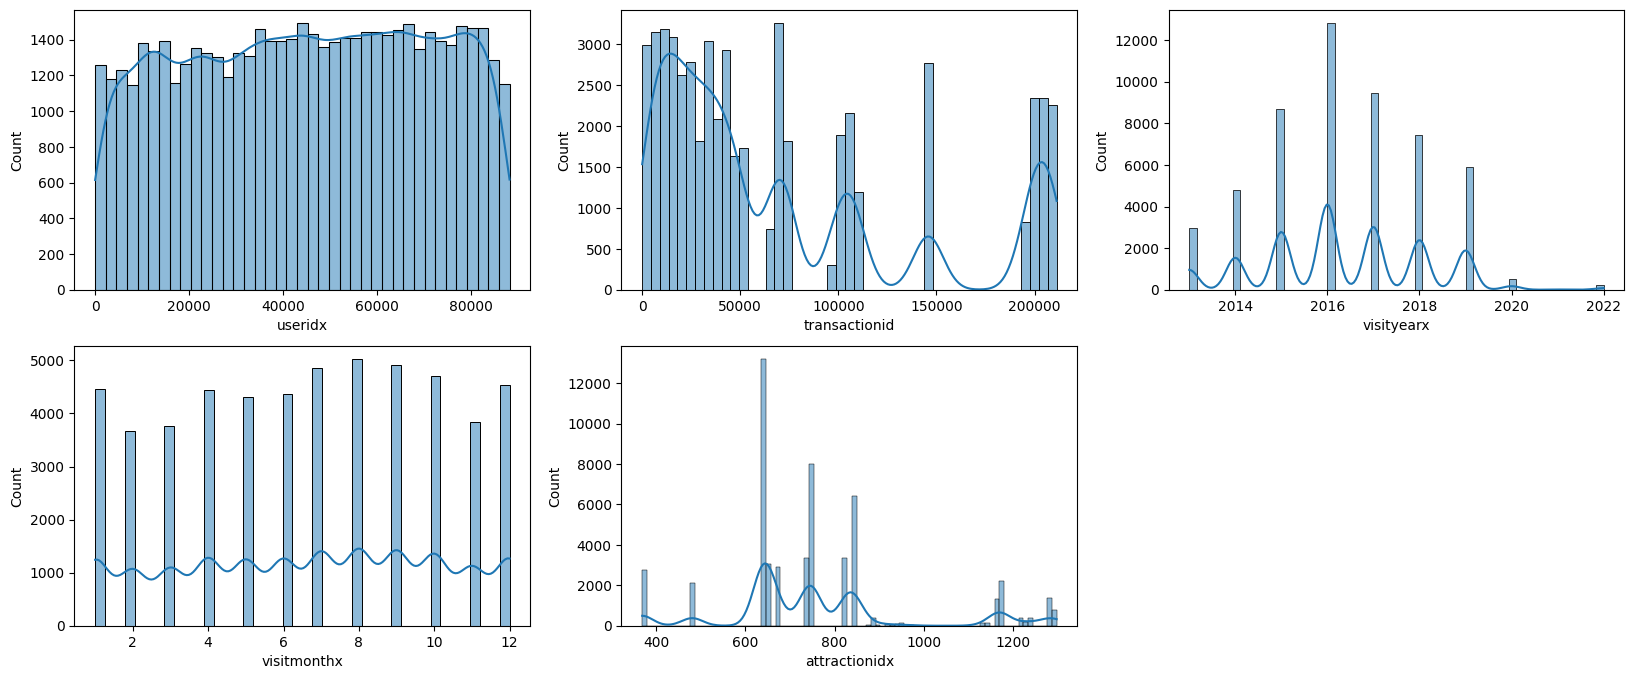

In [14]:
#Here we are analysing distribution for nuamerical features which was done earlier in EDA
nrows=2
ncols=3
k=0
plt.figure(figsize=(20,8))
for i in range(5):
        plt.subplot(2,3,k+1)
        sns.histplot(x[numerical[k]],kde=True)
        k+=1

In [15]:
#Here i am adding a covid_check because when i consider the year as numerical for maintaing the covid trend it could lead to bias my result so i add a covid check feature here.
covidyear=[2020,2021]
x["iscovid"]=x.visityearx.apply(lambda x : 1 if x in covidyear else 0)
x.head()

,useridx,continent,region,usercountry,usercity,transactionid,visityearx,visitmonthx,attractionidx,visitmodex,attraction,attractionaddress,attractiontype,attractioncity,attractioncountry,iscovid
0,14,Europe,Southern Europe,Portugal,Lagos,5661,2018,12,640,Friends,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,Cameroon,0
1,14,Europe,Southern Europe,Portugal,Lagos,67652,2018,12,748,Friends,Tegalalang Rice Terrace,"Jalan Raya Ceking, Tegalalang 80517 Indonesia",Points of Interest & Landmarks,Douala,Cameroon,0
2,14,Europe,Southern Europe,Portugal,Lagos,68777,2018,12,748,Friends,Tegalalang Rice Terrace,"Jalan Raya Ceking, Tegalalang 80517 Indonesia",Points of Interest & Landmarks,Douala,Cameroon,0
3,16,Asia,South East Asia,Indonesia,Jakarta,4735,2018,4,640,Family,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,Cameroon,0
4,16,Asia,South East Asia,Indonesia,Jakarta,5318,2017,12,640,Friends,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,Cameroon,0


<Axes: >

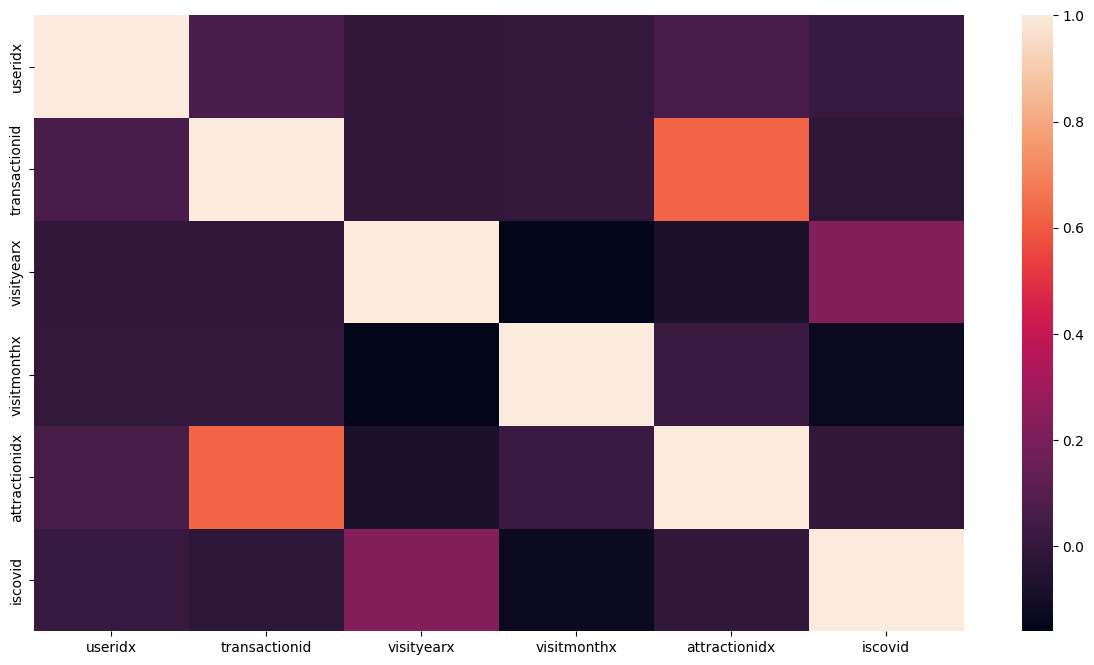

In [16]:
#Here i am analysing the correlation between numerical features and the ouput variable
plt.figure(figsize=(15,8))
sns.heatmap(x.corr(numeric_only=True))

In [17]:
#Here we are analysing the correlation of categorical features with the target variable rating
from scipy.stats import chi2_contingency
chitab=pd.DataFrame(columns=["column","chi2_score","null hypothesis","Target feature relation"])
k=0
for i in categorical:
    chi2_table=pd.crosstab(x[i],y)
    chi2_score=chi2_contingency(chi2_table)[1]
    alpha=0.05
    if chi2_score<0.05:
        chitab.loc[k]=[i,chi2_score,"Rejected","correlated"]
    else:
        chitab.loc[k]=[i,chi2_score,"Accepted","no correlation"]
    k+=1
chitab

,column,chi2_score,null hypothesis,Target feature relation
0,continent,3.903640e-45,Rejected,correlated
1,region,2.382207e-50,Rejected,correlated
2,usercountry,5.658270e-63,Rejected,correlated
3,usercity,2.673871e-71,Rejected,correlated
4,visitmodex,3.933519e-30,Rejected,correlated
5,attraction,0.000000e+00,Rejected,correlated
6,attractionaddress,0.000000e+00,Rejected,correlated
7,attractiontype,0.000000e+00,Rejected,correlated
8,attractioncity,6.041429e-69,Rejected,correlated
9,attractioncountry,1.318342e-64,Rejected,correlated


In [18]:
x=x.drop(["attraction","attractionaddress","usercity","attractioncity"],axis=1)

In [19]:
x.columns

Index(['useridx', 'continent', 'region', 'usercountry', 'transactionid',
       'visityearx', 'visitmonthx', 'attractionidx', 'visitmodex',
       'attractiontype', 'attractioncountry', 'iscovid'],
      dtype='str')

In [20]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler,RobustScaler
from category_encoders.binary import BinaryEncoder

In [21]:
# from sklearn.model_selection import train_test_split
# x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
# x_train.shape,x_test.shape,y_train.shape,y_test.shape

In [22]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(data, groups=data["useridx"]))
x_train = x.iloc[train_idx].copy()
x_test  = x.iloc[test_idx].copy()

y_train = y.iloc[train_idx]
y_test  = y.iloc[test_idx]

In [23]:
train_data=data.iloc[train_idx].copy()

In [24]:
train_data.columns

Index(['useridx', 'continent', 'region', 'usercountry', 'usercity',
       'transactionid', 'visityearx', 'visitmonthx', 'attractionidx',
       'ratingx', 'visitmodex', 'attraction', 'attractionaddress',
       'attractiontype', 'attractioncity', 'attractioncountry'],
      dtype='str')

In [25]:
attraction_mean_map=train_data.groupby("attractionidx")["ratingx"].mean()
global_mean=train_data["ratingx"].mean()
attraction_mean_map.head(),global_mean

(attractionidx
 369    3.432408
 481    4.268657
 640    4.265784
 650    3.967179
 673    3.794461
 Name: ratingx, dtype: float64,
 np.float64(4.159814762309801))

In [26]:
x_train["attraction_mean"] = x_train["attractionidx"].map(attraction_mean_map)
x_train["attraction_mean"].shape
x_train.attraction_mean.head()

0    4.265784
1    4.160269
2    4.160269
3    4.265784
4    4.265784
Name: attraction_mean, dtype: float64

In [27]:
x_test["attraction_mean"] = x_test["attractionidx"].map(attraction_mean_map).fillna(global_mean)
x_test.attraction_mean.head()

15    4.618123
17    4.265784
18    3.906178
19    4.265784
28    4.265784
Name: attraction_mean, dtype: float64

In [28]:
user_mean_map=train_data.groupby("useridx")["ratingx"].mean()
global_mean_user=user_mean_map.mean()
user_mean_map.head(),global_mean_user

(useridx
 14    4.666667
 16    4.700000
 20    4.000000
 23    5.000000
 26    5.000000
 Name: ratingx, dtype: float64,
 np.float64(4.167930675021898))

In [29]:
x_train["user_mean"] = x_train.useridx.map(user_mean_map).fillna(global_mean_user)
x_train["user_mean"].shape

(42324,)

In [30]:
x_test["user_mean"] = x_test.useridx.map(user_mean_map).fillna(global_mean_user)
x_test["user_mean"].shape

(10598,)

In [31]:
attraction_count=train_data.groupby("attractionidx")["useridx"].nunique()
attraction_count.head()

attractionidx
369    2051
481    1587
640    9195
650    2212
673    2181
Name: useridx, dtype: int64

In [32]:
x_train["attraction_count"] = x_train.attractionidx.map(attraction_count).fillna(1)
x_train.attraction_count.head()

0    9195
1    4290
2    4290
3    9195
4    9195
Name: attraction_count, dtype: int64

In [33]:
x_test["attraction_count"]=x_test.attractionidx.map(attraction_count).fillna(1)
x_test.attraction_count.head()

15     309
17    9195
18    1719
19    9195
28    9195
Name: attraction_count, dtype: int64

In [34]:
x_train=x_train.drop(columns=["useridx","transactionid","attractionidx"])
x_test=x_test.drop(columns=["useridx","transactionid","attractionidx"])

In [35]:
x_train["user_attraction_interaction"]=x_train["user_mean"]*x_train["attraction_mean"]
x_test["user_attraction_interaction"]=x_test["user_mean"]*x_test["attraction_mean"]

In [36]:
x_train["user_attraction_interaction"].head(),x_test["user_attraction_interaction"].head()

(0    19.906994
 1    19.414588
 2    19.414588
 3    20.049187
 4    20.049187
 Name: user_attraction_interaction, dtype: float64,
 15    19.248016
 17    17.779494
 18    16.280681
 19    17.779494
 28    17.779494
 Name: user_attraction_interaction, dtype: float64)

In [37]:
categoryx=[cols for cols in x_train.columns if x_train[cols].dtype=="str"]
numx=[cols for cols in x_train.columns if x_train[cols].dtype!="str"]
numx,categoryx

(['visityearx',
  'visitmonthx',
  'iscovid',
  'attraction_mean',
  'user_mean',
  'attraction_count',
  'user_attraction_interaction'],
 ['continent',
  'region',
  'usercountry',
  'visitmodex',
  'attractiontype',
  'attractioncountry'])

In [38]:
for i in categoryx:
    print(f"{i} unique values {x[i].nunique()}")

continent unique values 5
region unique values 22
usercountry unique values 153
visitmodex unique values 5
attractiontype unique values 17
attractioncountry unique values 2


In [39]:
ohe=[]
binenc=[]
for i in categoryx:
    if x_train[i].nunique()>6:
        binenc.append(i)
    else:
        ohe.append(i)
ohe,binenc

(['continent', 'visitmodex', 'attractioncountry'],
 ['region', 'usercountry', 'attractiontype'])

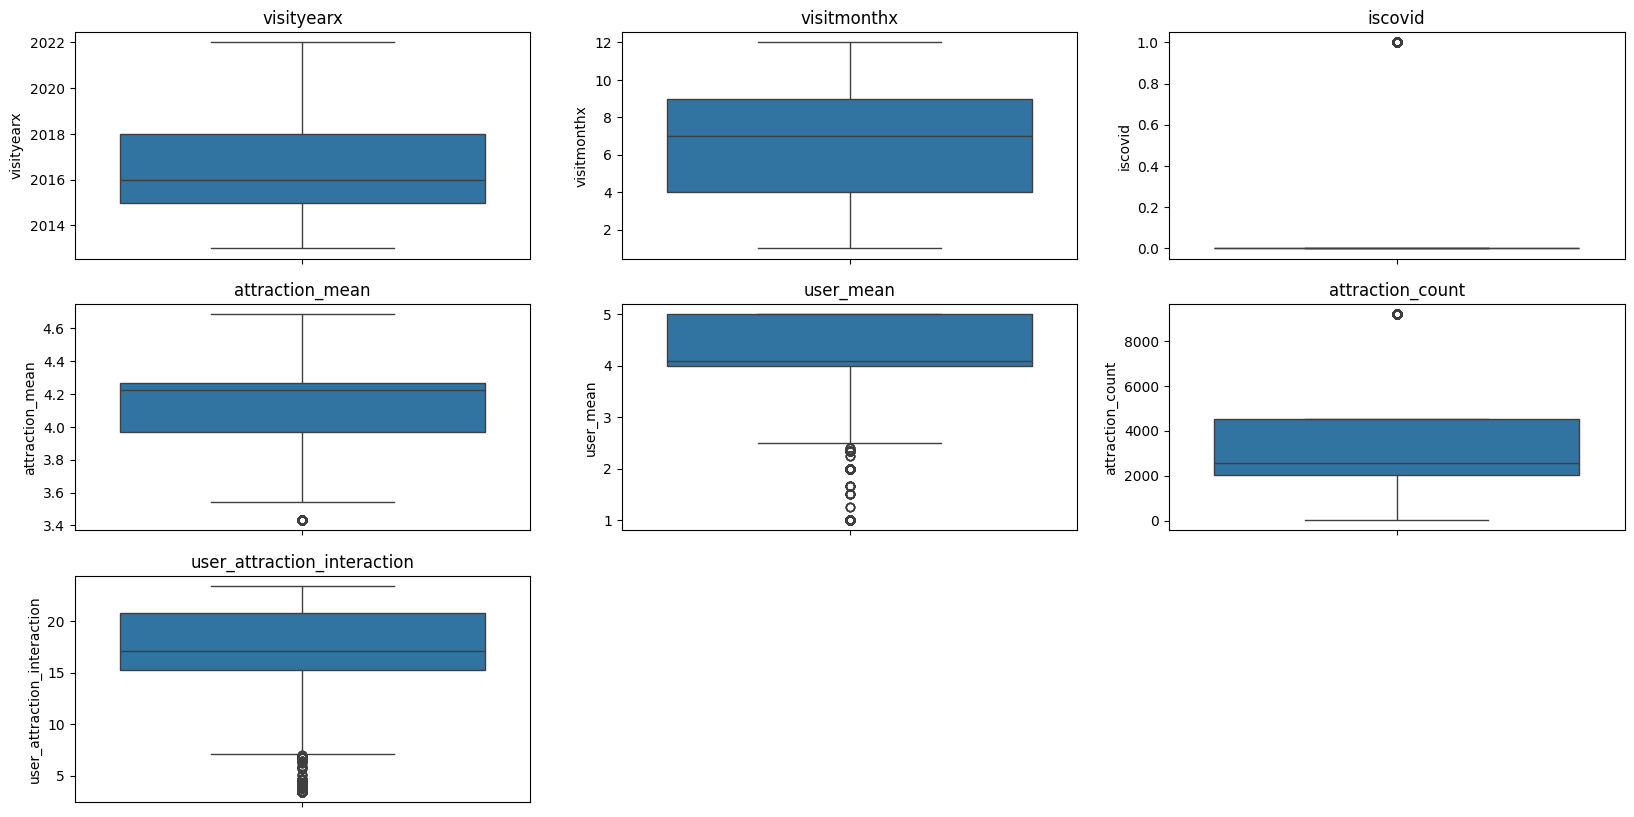

In [40]:
plt.figure(figsize=(20,10))
for i in range(len(numx)):
    plt.subplot(3,3,i+1)
    sns.boxplot(x_train[numx[i]])
    plt.title(numx[i])

In [41]:
def cap_outliers(x_train,cols):
    q1=x_train[cols].quantile(0.25)
    q2=x_train[cols].quantile(0.5)
    q3=x_train[cols].quantile(0.75)
    iqr=q3-q1
    lowerbound=q1-1.5*iqr
    upperbound=q3+1.5*iqr
    x_train.loc[x_train[cols]<lowerbound,cols]=lowerbound
    x_train.loc[x_train[cols]>upperbound,cols]=upperbound
    return x_train

for i in ["attraction_mean","user_mean","user_attraction_interaction"]:
    cap_outliers(x_train,i)

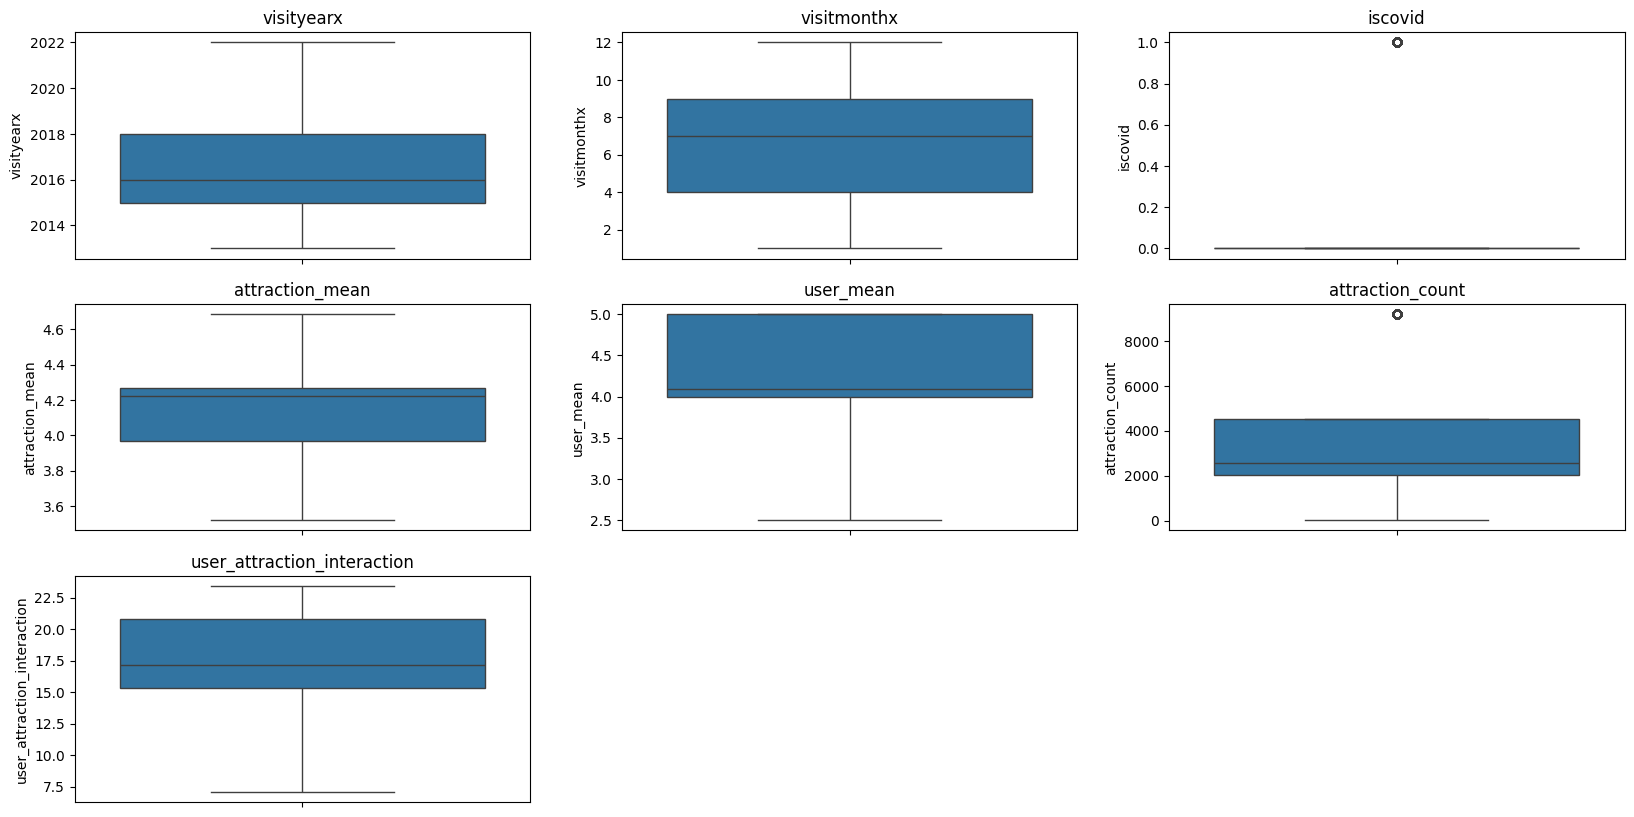

In [42]:
plt.figure(figsize=(20,10))
for i in range(len(numx)):
    plt.subplot(3,3,i+1)
    sns.boxplot(x_train[numx[i]])
    plt.title(numx[i])

In [43]:
# scales=["visityearx","visitmonthx","attraction_mean","attraction_count"]
# rscales=["user_mean","user_attraction_interaction"]
# scales,rscales

In [44]:
from sklearn.compose import ColumnTransformer
ct=ColumnTransformer(
    [
        ("OneHotEncoding",OneHotEncoder(),ohe),
        ("StandardScaler",StandardScaler(),numx),
        # ("Robustscaler",RobustScaler(),rscales),
        ("BinaryEncoder",BinaryEncoder(),binenc)
    ],
    remainder="drop"
)
x_train=ct.fit_transform(x_train)
x_test=ct.transform(x_test)

In [45]:
x_train.shape,y_train.shape

((42324, 37), (42324,))

In [46]:
from sklearn.decomposition import PCA
pca=PCA(n_components="mle",svd_solver="full")
x_train=pca.fit_transform(x_train)
x_test=pca.transform(x_test)
x_train.shape,y_train.shape

((42324, 34), (42324,))

In [47]:
x_train[0]

array([ 1.58349101e+00, -3.49262769e-01,  8.77342747e-01,  1.80814771e+00,
        1.28813630e-01,  1.04875593e+00, -6.81638769e-03, -2.33531089e-01,
        7.51925028e-02, -8.00209542e-01, -4.75750476e-01,  9.16657997e-01,
        9.05303455e-02,  1.71076804e-01, -3.77268756e-01, -7.70327475e-01,
        6.50534427e-02, -2.34104005e-01,  4.12204246e-01, -1.16278559e-01,
       -1.93705887e-01, -4.07495097e-02, -5.73080036e-02,  2.07549982e-01,
        1.96009668e-01, -2.33684329e-02,  2.06911917e-01, -3.35540072e-01,
       -1.99401156e-02, -3.72956311e-02,  9.98319392e-03,  2.48484514e-02,
        7.01627558e-04, -5.97766747e-03])

In [48]:
x_test[0]

array([ 7.09048347e-01,  7.02771992e+00,  1.67899270e+00,  3.13407056e-01,
        6.09762059e+00, -3.51447238e+00, -3.48026884e-01,  5.35239983e-01,
        5.74887064e-01,  1.95162723e-01, -2.13412910e-01,  1.37777096e+00,
       -2.74212819e-01, -2.42054755e-02, -4.13088926e-01,  1.93486572e-01,
       -3.51738337e-01, -9.12419344e-02,  1.41412363e-02,  1.96734098e-01,
        6.77246309e-02,  4.54669854e-03, -1.16216805e-01, -3.01262538e-02,
       -2.18687777e-01, -7.71204826e-01, -2.85996769e-03, -9.83722138e-04,
        3.06159385e-01, -6.23780539e-02,  4.23921841e-02, -1.42677035e-03,
        4.22952622e-02, -1.18253448e-03])

In [49]:
#Here i am excluding indices to avoid dummy variable trap or multicollinearity problem caused due to one hot encoding
# exclude_index=[0,5,10,13]
# include_index=np.arange(0,x_train.shape[1])
# index=[int(i) for i in include_index if i not in exclude_index]
# x_train=x_train[:,index]
# x_test=x_test[:,index]
# x_train[0]
#Here multicollinearity/dummy variable trap is not a problem for the tree based models and some non-linear models

In [50]:
data.ratingx.value_counts()

ratingx
5    23930
4    17964
3     7730
2     2035
1     1263
Name: count, dtype: int64

In [51]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.ensemble import GradientBoostingRegressor

In [52]:
gbr=GradientBoostingRegressor(n_estimators=9,random_state=42,max_depth=9)
gbr.fit(x_train,y_train)
y_pred=gbr.predict(x_test)
y_pred,y_test

(array([4.15962418, 4.17353068, 3.95803064, ..., 4.11154127, 4.24699937,
        4.06015422], shape=(10598,)),
 15       5
 17       4
 18       5
 19       5
 28       3
         ..
 52857    1
 52858    4
 52905    4
 52927    4
 52928    3
 Name: ratingx, Length: 10598, dtype: int64)

In [53]:
gbr.score(x_test,y_test),gbr.score(x_train,y_train)

(0.04174776343845832, 0.6580108914170179)

In [54]:
xgbr=XGBRegressor(max_depth=9,n_estimators=9)
xgbr.fit(x_train,y_train)
y_pred=xgbr.predict(x_test)
y_pred,y_test

(array([4.302194 , 4.0853677, 3.9540963, ..., 4.050612 , 4.4602547,
        3.9709811], shape=(10598,), dtype=float32),
 15       5
 17       4
 18       5
 19       5
 28       3
         ..
 52857    1
 52858    4
 52905    4
 52927    4
 52928    3
 Name: ratingx, Length: 10598, dtype: int64)

In [55]:
xgbr.score(x_test,y_test),xgbr.score(x_train,y_train)

(0.05173206329345703, 0.803727388381958)

In [56]:
rfr=RandomForestRegressor(n_estimators=11,random_state=42,max_depth=10)
rfr.fit(x_train,y_train)
y_pred=rfr.predict(x_test)
y_pred,y_test

(array([4.05782848, 4.55601155, 3.85291297, ..., 4.04689287, 4.31333863,
        4.00631074], shape=(10598,)),
 15       5
 17       4
 18       5
 19       5
 28       3
         ..
 52857    1
 52858    4
 52905    4
 52927    4
 52928    3
 Name: ratingx, Length: 10598, dtype: int64)

In [57]:
rfr.score(x_test,y_test),rfr.score(x_train,y_train)

(0.0512042400462045, 0.7813047089345916)

In [58]:
dtc=DecisionTreeRegressor(random_state=42,max_depth=9)
dtc.fit(x_train,y_train)
y_pred=dtc.predict(x_test)
y_pred,y_test

(array([5.        , 4.19148936, 4.05263158, ..., 4.02696629, 4.5432526 ,
        3.935247  ], shape=(10598,)),
 15       5
 17       4
 18       5
 19       5
 28       3
         ..
 52857    1
 52858    4
 52905    4
 52927    4
 52928    3
 Name: ratingx, Length: 10598, dtype: int64)

In [59]:
dtc.score(x_test,y_test),dtc.score(x_train,y_train)

(0.011988490246027883, 0.7590902834604452)

In [60]:
from sklearn.model_selection import RandomizedSearchCV
model={
    "DecisionTreeRegressor":DecisionTreeRegressor(),
    "RandomForestRegressor":RandomForestRegressor(),
    "SVR":SVR(),
    "XGBRegressor":XGBRegressor(),
    "GradientBoostingRegressor":GradientBoostingRegressor()
}

param_grid={
    "DecisionTreeRegressor":{
        "max_depth":[6,7,8,9],
        "criterion":["squared_error"]
    },
    "RandomForestRegressor":{
        "max_depth":[6,7,8,9],
        "criterion":["squared_error"],
        "n_estimators":[5,6,7,8,9],
    },
    "SVR":{
        "kernel":["rbf"],
        "epsilon":[0.1]
    },
    "XGBRegressor":{
        "n_estimators":[6,7,8,9],
        "max_depth":[6,7,8,9]
    },
    "GradientBoostingRegressor":{
        "n_estimators":[10,15,5],
        "learning_rate":[0.1]
    }
}

In [61]:
x_train.shape,y_train.shape,x_test.shape,y_test.shape

((42324, 34), (42324,), (10598, 34), (10598,))

In [62]:
x_comb=np.concatenate((x_train,x_test),axis=0)
y_comb=np.concatenate((y_train,y_test),axis=0)
x_comb.shape,y_comb.shape

((52922, 34), (52922,))

In [63]:
# gsc_table=pd.DataFrame(columns=["model","score","best_params","best_estimator"])
# j=0
# for i in model:
#     gsc=RandomizedSearchCV(estimator=model[i],param_distributions=param_grid[i],cv=5,return_train_score=True,verbose=3)
#     gsc.fit(x_train,y_train)
#     gsc_table.loc[j]=[model[i],gsc.best_score_,gsc.best_params_,gsc.best_estimator_]
#     j+=1
# gsc_table

#### Here i am analysing the variation in my training and testing data 

In [64]:
model = XGBRegressor(n_estimators=9,max_depth=6)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
y_pred.flatten(),y_test

(array([3.9184265, 4.2058506, 3.8975525, ..., 4.0593166, 4.300058 ,
        4.0473194], shape=(10598,), dtype=float32),
 15       5
 17       4
 18       5
 19       5
 28       3
         ..
 52857    1
 52858    4
 52905    4
 52927    4
 52928    3
 Name: ratingx, Length: 10598, dtype: int64)

In [65]:
y_train.var(),y_test.var()

(np.float64(0.9378118977325923), np.float64(0.9587939776437455))

In [66]:
y_train.mean(),y_test.mean()

(np.float64(4.159814762309801), np.float64(4.148801660690697))

In [67]:
y_train.value_counts(normalize=True),y_test.value_counts(normalize=True)

(ratingx
 5    0.452486
 4    0.340374
 3    0.145166
 2    0.038418
 1    0.023556
 Name: proportion, dtype: float64,
 ratingx
 5    0.450934
 4    0.335724
 3    0.149651
 2    0.038592
 1    0.025099
 Name: proportion, dtype: float64)

In [69]:
x.columns

Index(['useridx', 'continent', 'region', 'usercountry', 'transactionid',
       'visityearx', 'visitmonthx', 'attractionidx', 'visitmodex',
       'attractiontype', 'attractioncountry', 'iscovid'],
      dtype='str')

In [70]:
col_select=[cols for cols in data.columns if cols not in ["useridx","transactionid","attractionidx","ratingx","attraction","attractionaddress","usercity","attractioncity"]]
col_select

['continent',
 'region',
 'usercountry',
 'visityearx',
 'visitmonthx',
 'visitmodex',
 'attractiontype',
 'attractioncountry']

In [71]:
x1=x.loc[0,col_select]
x1.head()

continent               Europe
region         Southern Europe
usercountry           Portugal
visityearx                2018
visitmonthx                 12
Name: 0, dtype: object

In [72]:
import joblib
joblib.dump(model,"Attraction_rating_prediction_model.pkl")

['Attraction_rating_prediction_model.pkl']

In [73]:
def predict_attraction_rating(sample,covidyear,user_mean_map,global_mean_user,attraction_mean_map,global_mean,attraction_count,ct,pca,model):
    x_test = sample.copy()
    x_test=x_test.to_frame().T
    x_test["iscovid"] = x_test.visityearx.apply(lambda x : 1 if x in covidyear else 0)
    x_test["user_mean"] = x_test.useridx.map(user_mean_map).fillna(global_mean_user)
    x_test["attraction_mean"] = x_test["attractionidx"].map(attraction_mean_map).fillna(global_mean)
    x_test["attraction_count"] = x_test.attractionidx.map(attraction_count).fillna(1)
    x_test.drop(columns=["useridx","transactionid","attractionidx","ratingx"],inplace=True)
    x_test["user_attraction_interaction"]=x_test["user_mean"]*x_test["attraction_mean"]
    x_test=ct.transform(x_test)
    x_test=pca.transform(x_test)
    return model.predict(x_test)

In [74]:
sample=train_data.loc[0]
sample

useridx                                                   14
continent                                             Europe
region                                       Southern Europe
usercountry                                         Portugal
usercity                                               Lagos
transactionid                                           5661
visityearx                                              2018
visitmonthx                                               12
attractionidx                                            640
ratingx                                                    4
visitmodex                                           Friends
attraction                    Sacred Monkey Forest Sanctuary
attractionaddress    Jl. Monkey Forest, Ubud 80571 Indonesia
attractiontype                       Nature & Wildlife Areas
attractioncity                                        Douala
attractioncountry                                   Cameroon
Name: 0, dtype: object

In [75]:
predict_attraction_rating(sample,covidyear,user_mean_map,global_mean_user,attraction_mean_map,global_mean,attraction_count,ct,pca,joblib.load("Attraction_rating_prediction_model.pkl"))

array([4.61242], dtype=float32)

In [76]:
from sklearn.base import BaseEstimator, TransformerMixin

class RatingFeatureBuilder(BaseEstimator, TransformerMixin):
    def __init__(self, covidyear, user_mean_map, global_mean_user,
                 attraction_mean_map, global_mean, attraction_count_map):
        
        self.covidyear = covidyear
        self.user_mean_map = user_mean_map
        self.global_mean_user = global_mean_user
        self.attraction_mean_map = attraction_mean_map
        self.global_mean = global_mean  
        self.attraction_count_map = attraction_count_map

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        X["iscovid"] = X["visityearx"].apply(
            lambda x: 1 if x in self.covidyear else 0
        )

        X["user_mean"] = X["useridx"].map(
            self.user_mean_map
        ).fillna(self.global_mean_user)

        X["attraction_mean"] = X["attractionidx"].map(
            self.attraction_mean_map
        ).fillna(self.global_mean)

        X["attraction_count"] = X["attractionidx"].map(
            self.attraction_count_map
        ).fillna(1)

        X["user_attraction_interaction"] = (
            X["user_mean"] * X["attraction_mean"]
        )
        
        X = X.drop(columns=["useridx","transactionid","attractionidx"], errors="ignore")
        
        return X

In [77]:
from sklearn.pipeline import Pipeline

full_pipeline = Pipeline(steps=[
    ("feature_builder", RatingFeatureBuilder(
        covidyear=covidyear,
        user_mean_map=user_mean_map,
        global_mean_user=global_mean_user,
        attraction_mean_map=attraction_mean_map,
        global_mean=global_mean,
        attraction_count_map=attraction_count
    )),
    
    ("preprocessing", ct),
    ("pca", pca),
    ("model", joblib.load("Attraction_rating_prediction_model.pkl"))
])

In [78]:
sample

useridx                                                   14
continent                                             Europe
region                                       Southern Europe
usercountry                                         Portugal
usercity                                               Lagos
transactionid                                           5661
visityearx                                              2018
visitmonthx                                               12
attractionidx                                            640
ratingx                                                    4
visitmodex                                           Friends
attraction                    Sacred Monkey Forest Sanctuary
attractionaddress    Jl. Monkey Forest, Ubud 80571 Indonesia
attractiontype                       Nature & Wildlife Areas
attractioncity                                        Douala
attractioncountry                                   Cameroon
Name: 0, dtype: object

In [79]:
full_pipeline.predict(sample.to_frame().T)[0]

np.float32(4.61242)

In [80]:
joblib.dump(full_pipeline,"Attraction_rating_full_pipeline.pkl")

['Attraction_rating_full_pipeline.pkl']

In [81]:
pred=joblib.load("Attraction_rating_full_pipeline.pkl").predict(sample.to_frame().T)[0]
pred

np.float32(4.61242)